# Car_Price_Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/Users/dineshkqryadav97gmail.com/Downloads/cardekho.csv")

In [3]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


# Dataset Inspection & Cleaning as well.

In [4]:
df.shape

(8128, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [6]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [7]:
df.dtypes

name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

In [8]:
# Missing values
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [9]:
df.isnull().sum().sort_values(ascending=False)

mileage(km/ltr/kg)    221
engine                221
seats                 221
max_power             215
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
dtype: int64

In [10]:
# Duplicate Row
df.duplicated().sum()

np.int64(1202)

In [11]:
# Remove duplicate row.
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

# Clean categorical columns

In [13]:
print("Fuel:", df["fuel"].unique())
print("Seller Type:", df["seller_type"].unique())
print("Transmission:", df["transmission"].unique())
print("Owner:", df["owner"].unique())

Fuel: ['Diesel' 'Petrol' 'LPG' 'CNG']
Seller Type: ['Individual' 'Dealer' 'Trustmark Dealer']
Transmission: ['Manual' 'Automatic']
Owner: ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


# Standardize text columns.  ( We can safely remove unnecessary leading/trailing spaces ) 


In [14]:
categorical_columns = ["fuel", "seller_type", "transmission", "owner"]

for col in categorical_columns:
    df[col] = df[col].str.strip()

In [15]:
for col in categorical_columns:
    print(col, df[col].unique())

fuel ['Diesel' 'Petrol' 'LPG' 'CNG']
seller_type ['Individual' 'Dealer' 'Trustmark Dealer']
transmission ['Manual' 'Automatic']
owner ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


In [16]:
df.shape

(6926, 12)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   object 
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6718 non-null   float64
 9   engine              6718 non-null   float64
 10  max_power           6721 non-null   object 
 11  seats               6718 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 703.4+ KB


# Handle Missing Values + Clean Numeric Columns

In [18]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [19]:
df[["mileage(km/ltr/kg)", "engine", "max_power", "seats"]].isnull().sum()

mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [20]:
df[["mileage(km/ltr/kg)", "engine", "max_power", "seats"]].dtypes

mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

# Convert max_power into numeric because its data type are in object. we have to convert into float value.

In [21]:
df["max_power"] = pd.to_numeric(
    df["max_power"].str.split().str[0],
    errors="coerce"
)

In [22]:
df["max_power"].head(10)

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
5     81.86
6     57.50
7     37.00
8     67.10
9     68.10
Name: max_power, dtype: float64

In [23]:
df["max_power"].dtype

dtype('float64')

In [24]:
# After converting max_power's dtype into float so the missing value will be slightly increase then before.

df[["mileage(km/ltr/kg)", "engine", "max_power", "seats"]].isnull().sum()

mileage(km/ltr/kg)    208
engine                208
max_power             206
seats                 208
dtype: int64

# Fill missing numerical values

In [25]:
## Fill missing values with the median of each numeric column.

numeric_columns = [
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [26]:
# Verify the missing values now  and dtypes as well
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [27]:
df[["mileage(km/ltr/kg)", "engine", "max_power", "seats"]].dtypes

mileage(km/ltr/kg)    float64
engine                float64
max_power             float64
seats                 float64
dtype: object

# Feature Engineering

In [28]:
# car_age = current year - manufacturing year

df["car_age"] = 2026 - df["year"]

In [29]:
df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


### Above the output shows the year means  manufactured date and car_age tell us that how old car is. 

# Extract the car brand

In [30]:
df["brand"] = df["name"].str.split().str[0]

In [31]:
df[["name", "brand"]].head(10)

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti
5,Hyundai Xcent 1.2 VTVT E Plus,Hyundai
6,Maruti Wagon R LXI DUO BSIII,Maruti
7,Maruti 800 DX BSII,Maruti
8,Toyota Etios VXD,Toyota
9,Ford Figo Diesel Celebration Edition,Ford


# Check the new features


In [32]:
df[["name", "year", "brand", "car_age"]].head(10)

,name,year,brand,car_age
0,Maruti Swift Dzire VDI,2014,Maruti,12
1,Skoda Rapid 1.5 TDI Ambition,2014,Skoda,12
2,Honda City 2017-2020 EXi,2006,Honda,20
3,Hyundai i20 Sportz Diesel,2010,Hyundai,16
4,Maruti Swift VXI BSIII,2007,Maruti,19
5,Hyundai Xcent 1.2 VTVT E Plus,2017,Hyundai,9
6,Maruti Wagon R LXI DUO BSIII,2007,Maruti,19
7,Maruti 800 DX BSII,2001,Maruti,25
8,Toyota Etios VXD,2011,Toyota,15
9,Ford Figo Diesel Celebration Edition,2013,Ford,13


# Check brand distribution

In [33]:
df["brand"].value_counts().head(15)

brand
Maruti           2165
Hyundai          1267
Mahindra          723
Tata              647
Honda             362
Ford              361
Toyota            357
Chevrolet         216
Renault           206
Volkswagen        174
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Name: count, dtype: int64

# Check car-age range

In [34]:
df["car_age"].describe()

count    6926.000000
mean       12.579700
std         4.078286
min         6.000000
25%         9.000000
50%        12.000000
75%        15.000000
max        43.000000
Name: car_age, dtype: float64

# EDA (Exploratory Data Analysis)

# Celling price Distribution (This graph tells us how many times different car prices appear in the dataset.)

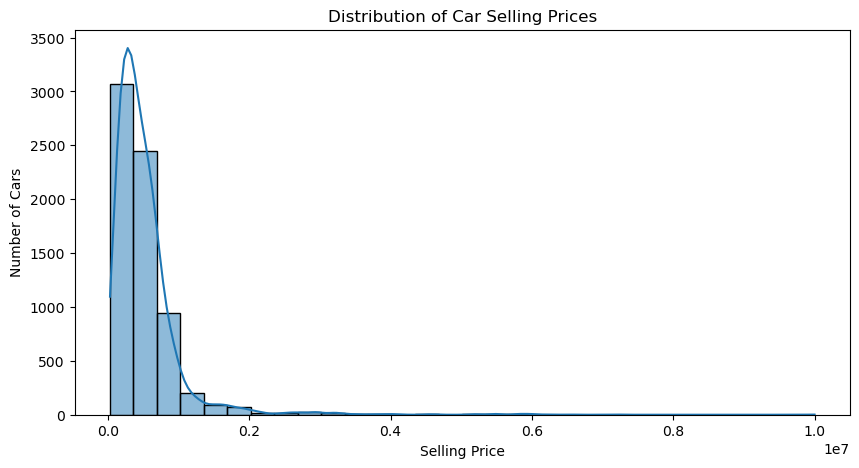

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

## Observation
###This graph shows that most cars have lower selling prices, while only a few cars have very high selling prices.

# Price vs Fuel Type

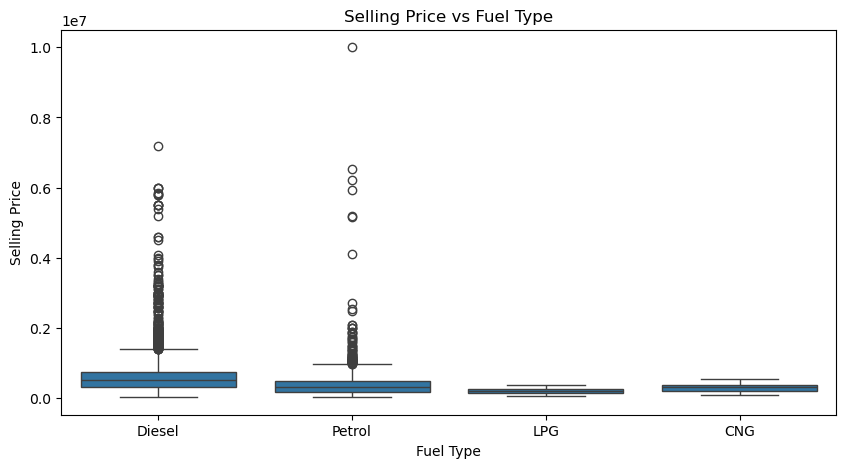

In [36]:
plt.figure(figsize=(10, 5))

sns.boxplot(x="fuel", y="selling_price", data=df)

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

## Observation
###This graph shows that Diesel and Petrol cars have a wider range of selling prices, while LPG and CNG cars have a smaller price range.

# Price vs Car Age


In [37]:
df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


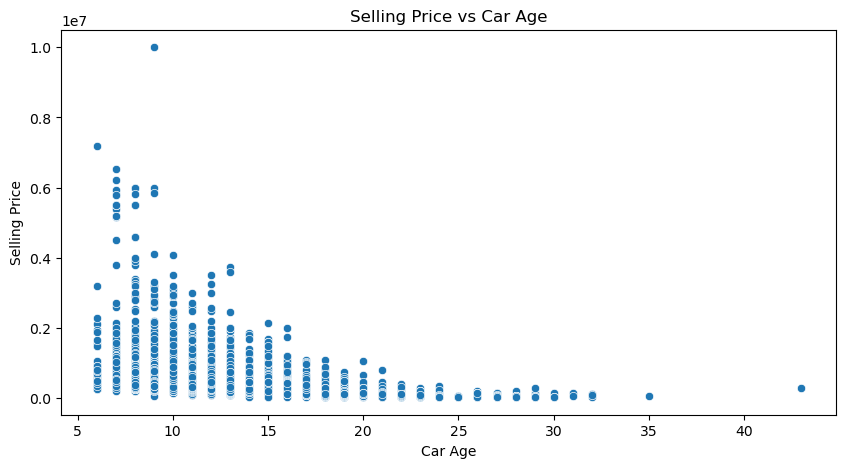

In [38]:
plt.figure(figsize=(10, 5))

sns.scatterplot(x="car_age", y="selling_price", data=df)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

## Observation
###This graph shows that younger cars generally have higher selling prices, while older cars tend to have lower selling prices.

# Encoding Categorical Variables.( text convert into number )

In [39]:
# we have to convert these categorical valriable into number.
df.select_dtypes(include="object").columns

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner', 'brand'], dtype='object')

# Create the modeling dataset 

In [40]:
# Target variable
y = df["selling_price"]

# Input features
X = df.drop(columns=["selling_price", "name"])

In [41]:
X.head()

,year,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,2014,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,12,Maruti
1,2014,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,Skoda
2,2006,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,20,Honda
3,2010,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,16,Hyundai
4,2007,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,19,Maruti


## Convert all the categorical into numerical columns using pd.get_dummies().


In [42]:
X = pd.get_dummies(
    X,
    columns=["fuel", "seller_type", "transmission", "owner", "brand"],
    drop_first=True
)

X.head()

,year,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,145500,23.40,1248.0,74.00,5.0,12,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2014,120000,21.14,1498.0,103.52,5.0,12,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,2006,140000,17.70,1497.0,78.00,5.0,20,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,2010,127000,23.00,1396.0,90.00,5.0,16,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2007,120000,16.10,1298.0,88.20,5.0,19,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [43]:
X.shape

(6926, 48)

In [44]:
X.dtypes

year                              int64
km_driven                         int64
mileage(km/ltr/kg)              float64
engine                          float64
max_power                       float64
seats                           float64
car_age                           int64
fuel_Diesel                        bool
fuel_LPG                           bool
fuel_Petrol                        bool
seller_type_Individual             bool
seller_type_Trustmark Dealer       bool
transmission_Manual                bool
owner_Fourth & Above Owner         bool
owner_Second Owner                 bool
owner_Test Drive Car               bool
owner_Third Owner                  bool
brand_Ashok                        bool
brand_Audi                         bool
brand_BMW                          bool
brand_Chevrolet                    bool
brand_Daewoo                       bool
brand_Datsun                       bool
brand_Fiat                         bool
brand_Force                        bool


# Feature Correlation Heatmap

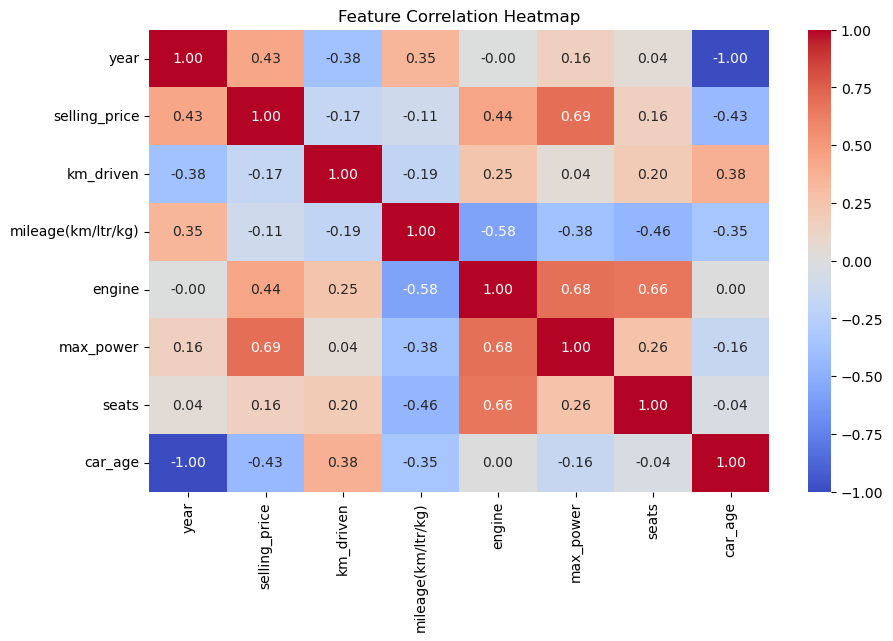

In [45]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

# Train/Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [47]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5540, 48), (1386, 48), (5540,), (1386,))

# Train Regression Models

In [48]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Random Forest

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calculate Evaluation Metrics

In [50]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

# Compare both model

In [51]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,133098.533351,262236.186554,0.686452
1,Random Forest,72775.382424,129828.179534,0.923148


# Feature Importance And Chart

In [52]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

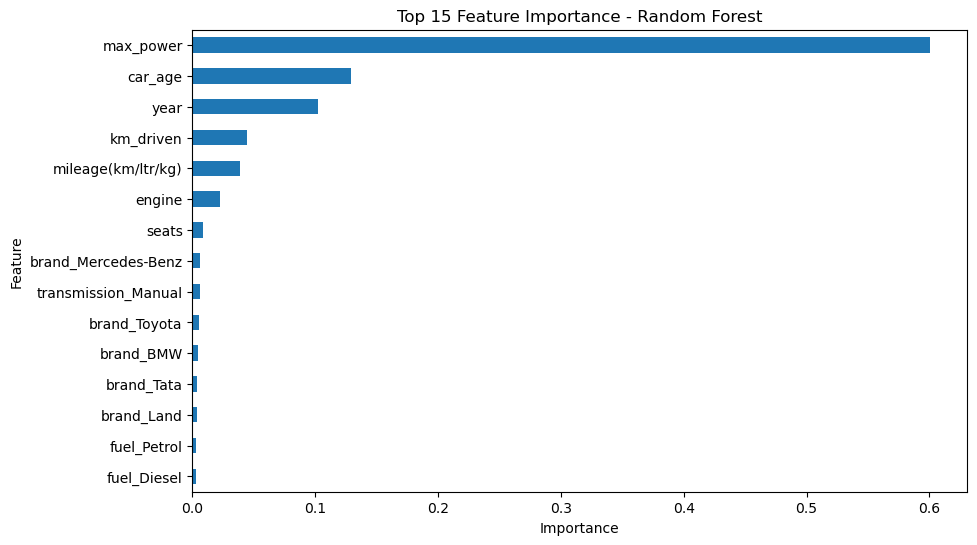

In [53]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Predict price for a sample car

In [54]:
sample_index = 17

sample = X_test.iloc[[sample_index]]
car_name = df.loc[sample.index[0], "name"]

predicted_price = rf_model.predict(sample)[0]

print("Car Name:", car_name)
print("Predicted Price: ₹", round(predicted_price, 2))

Car Name: Maruti Swift Dzire VDI
Predicted Price: ₹ 710815.43


# Final Model Summary

In [55]:
print("Best Model: Random Forest")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("Sample Predicted Price:", predicted_price)

Best Model: Random Forest
R2 Score: 0.9231477699878259
MAE: 72775.38242407635
RMSE: 129828.17953371268
Sample Predicted Price: 710815.4285714285


In [56]:
# Save final model.

import joblib

joblib.dump(rf_model, "car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

### The **Random Forest Regressor** performed better than Linear Regression for predicting 
### used-car selling prices, with an **R² score of approximately 0.92**. The results show 
### that **max power, car age, year, km driven, and mileage** are the most important factors
### affecting car prices. Overall, the model provides a good prediction of used-car selling prices.
